In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_supply_chain.csv")

print("✅ Data Loaded")
df.head()

✅ Data Loaded


,shipment_id,date,origin_port,destination_port,transport_mode,product_category,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,weather_condition,carrier_reliability_score,lead_time_days,disruption_occurred,year,month,risk_level,transport_category,efficiency_score
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,2025,10,Medium,Moderate,0.020406
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,2024,4,High,Moderate,0.014122
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2024,1,Medium,Moderate,0.053668
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,2024,10,Low,Moderate,0.015370
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,2024,9,Low,Fast,0.494000


In [2]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [17]:
# ===============================
# Disruption Rate
# ===============================

disruption_rate = df['disruption_occurred'].mean() * 100
print(f"🚨 Disruption Rate: {disruption_rate:.2f}%")

🚨 Disruption Rate: 61.26%


In [18]:
# ===============================
# Average Lead Time
# ===============================

print("⏱️ Avg Lead Time:", df['lead_time_days'].mean())


⏱️ Avg Lead Time: 19.355386000000003


In [19]:
# ===============================
# Avg Carrier Reliability
# ===============================

print("🚚 Avg Reliability:", df['carrier_reliability_score'].mean())

🚚 Avg Reliability: 0.7543872


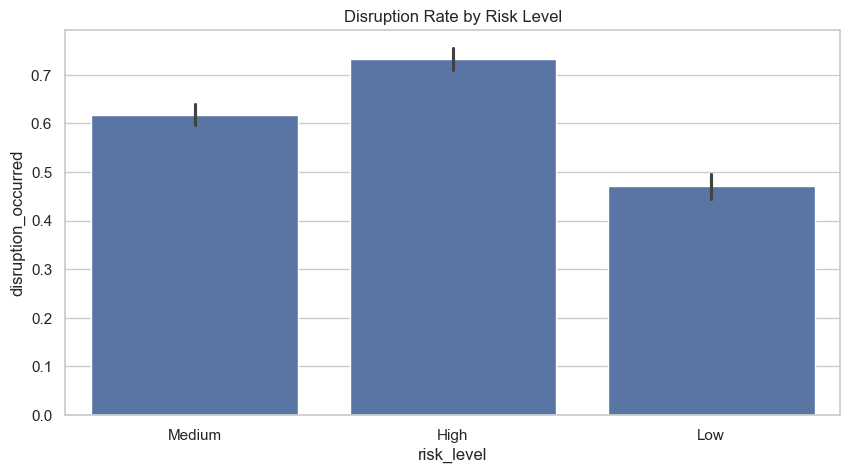

In [6]:
# ===============================
# Risk Level vs Disruption
# ===============================

sns.barplot(x='risk_level', y='disruption_occurred', data=df)
plt.title("Disruption Rate by Risk Level")
plt.show()

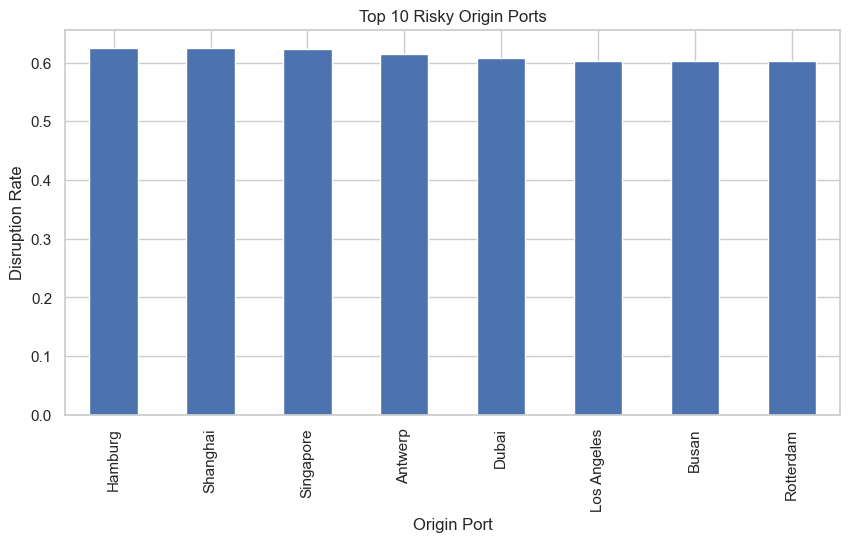

In [7]:
# ===============================
# Top Risky Origin Ports
# ===============================

top_risk_ports = df.groupby('origin_port')['disruption_occurred'].mean().sort_values(ascending=False).head(10)

top_risk_ports.plot(kind='bar')
plt.title("Top 10 Risky Origin Ports")
plt.xlabel("Origin Port")
plt.ylabel("Disruption Rate")
plt.show()

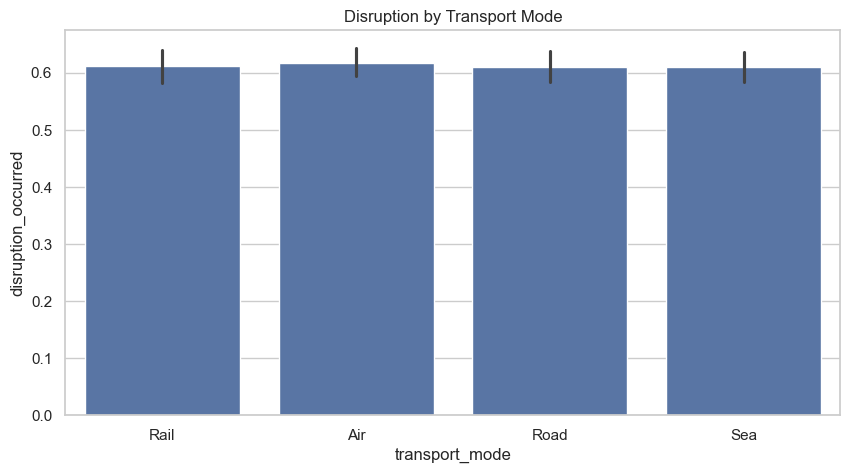

In [8]:
# ===============================
# Transport Mode vs Risk
# ===============================

sns.barplot(x='transport_mode', y='disruption_occurred', data=df)
plt.title("Disruption by Transport Mode")
plt.show()

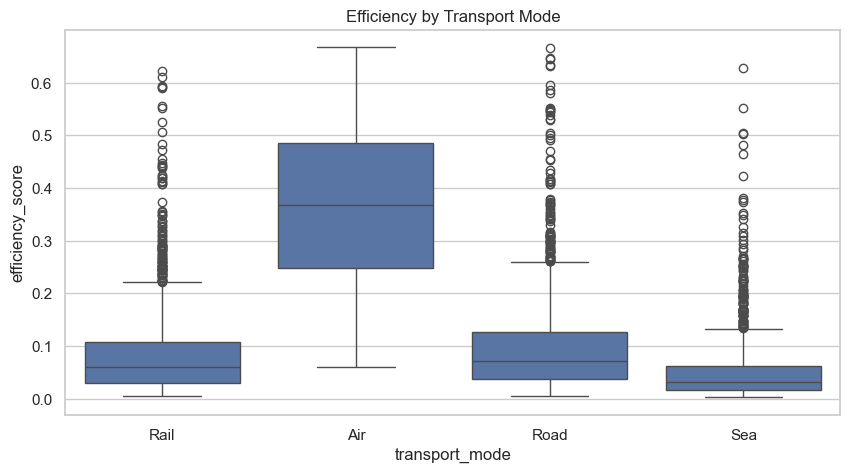

In [9]:
# ===============================
# Transport Efficiency
# ===============================

sns.boxplot(x='transport_mode', y='efficiency_score', data=df)
plt.title("Efficiency by Transport Mode")
plt.show()

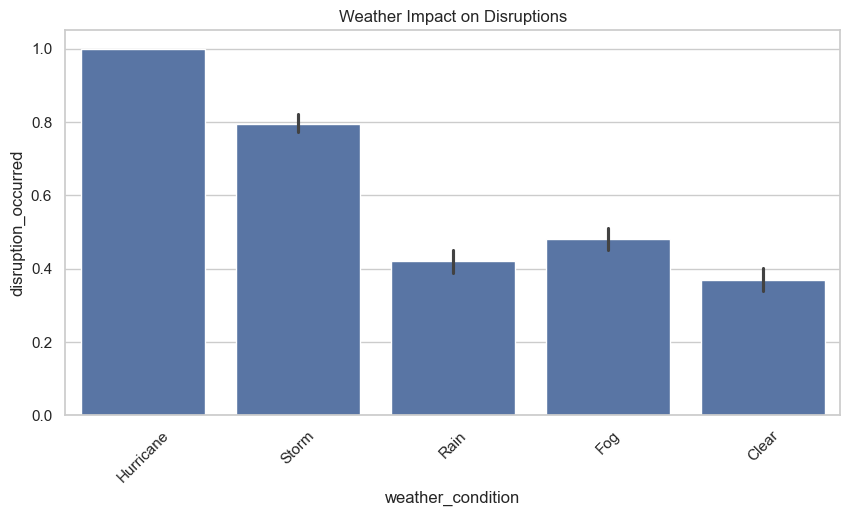

In [10]:
# ===============================
# Weather Impact
# ===============================

sns.barplot(x='weather_condition', y='disruption_occurred', data=df)
plt.xticks(rotation=45)
plt.title("Weather Impact on Disruptions")
plt.show()

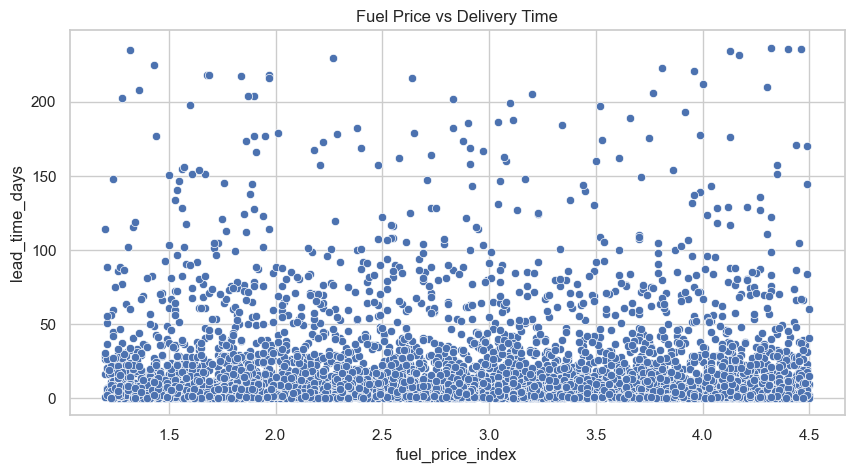

In [11]:
# ===============================
# Fuel Price Impact
# ===============================

sns.scatterplot(x='fuel_price_index', y='lead_time_days', data=df)
plt.title("Fuel Price vs Delivery Time")
plt.show()

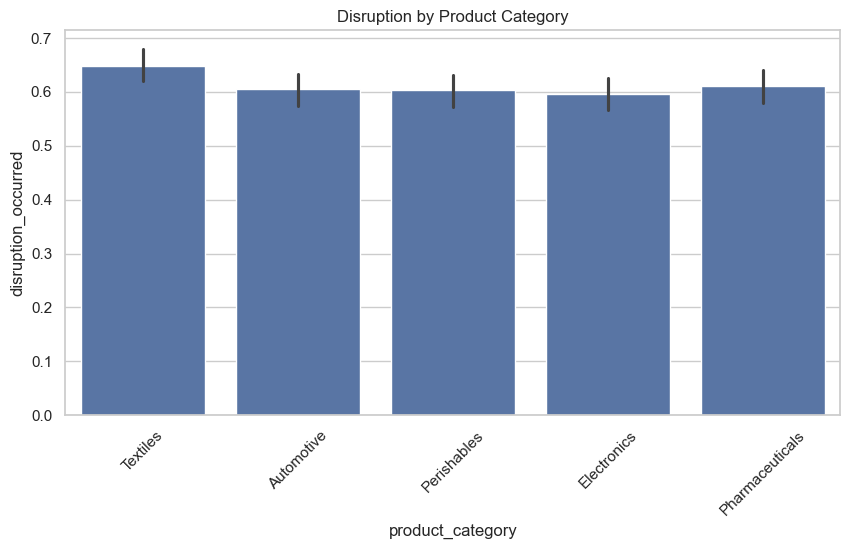

In [12]:
# ===============================
# Product Category Risk
# ===============================

sns.barplot(x='product_category', y='disruption_occurred', data=df)
plt.xticks(rotation=45)
plt.title("Disruption by Product Category")
plt.show()

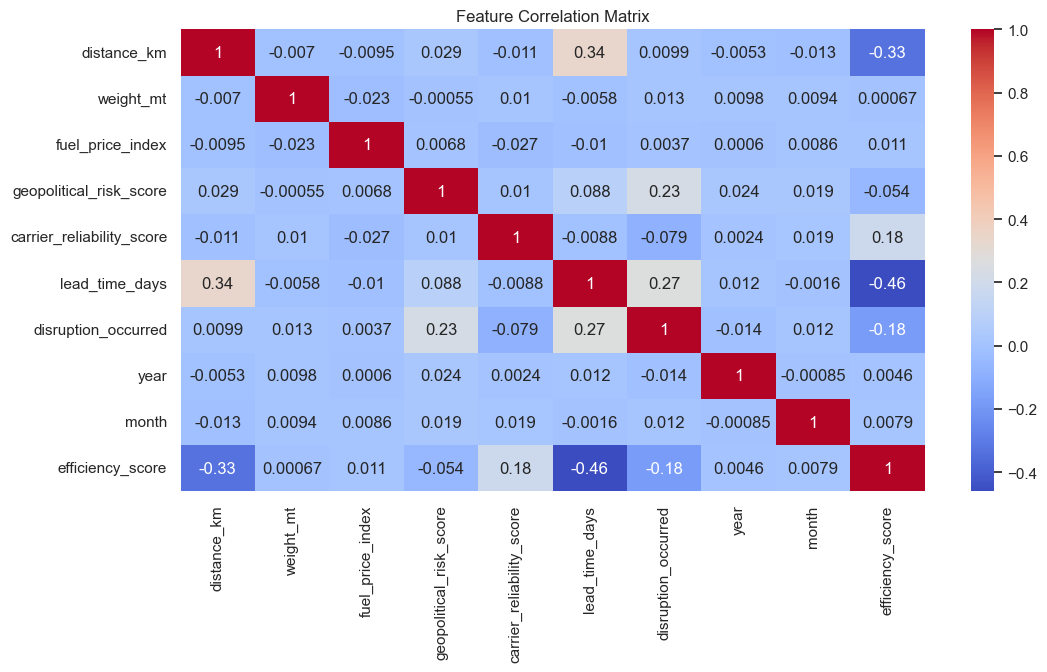

In [13]:
# ===============================
# Correlation Heatmap
# ===============================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

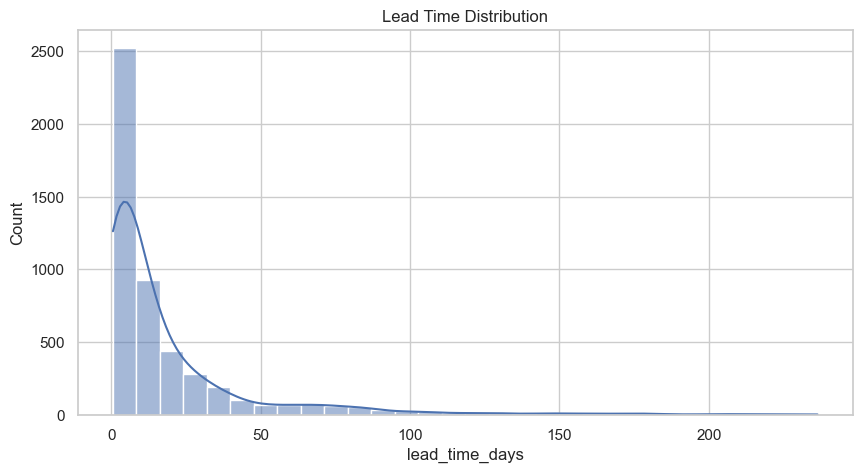

In [14]:
# ===============================
# Lead Time Distribution
# ===============================

sns.histplot(df['lead_time_days'], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.show()

In [20]:
# ===============================
# High Risk + Low Reliability
# ===============================

critical = df[
    (df['risk_level'] == 'High') & 
    (df['carrier_reliability_score'] < 0.6)
]

print("🚨 Critical Shipments:", len(critical))

🚨 Critical Shipments: 285


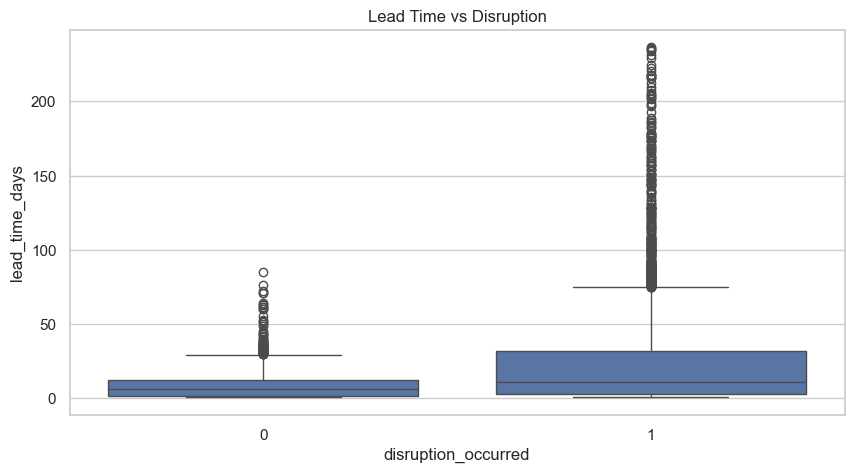

In [16]:
# ===============================
# Delay Drivers
# ===============================

sns.boxplot(x='disruption_occurred', y='lead_time_days', data=df)
plt.title("Lead Time vs Disruption")
plt.show()

In [21]:
print(top_risk_ports)

origin_port
Hamburg        0.624791
Shanghai       0.624224
Singapore      0.622705
Antwerp        0.614173
Dubai          0.608197
Los Angeles    0.602990
Busan          0.602699
Rotterdam      0.602167
Name: disruption_occurred, dtype: float64
